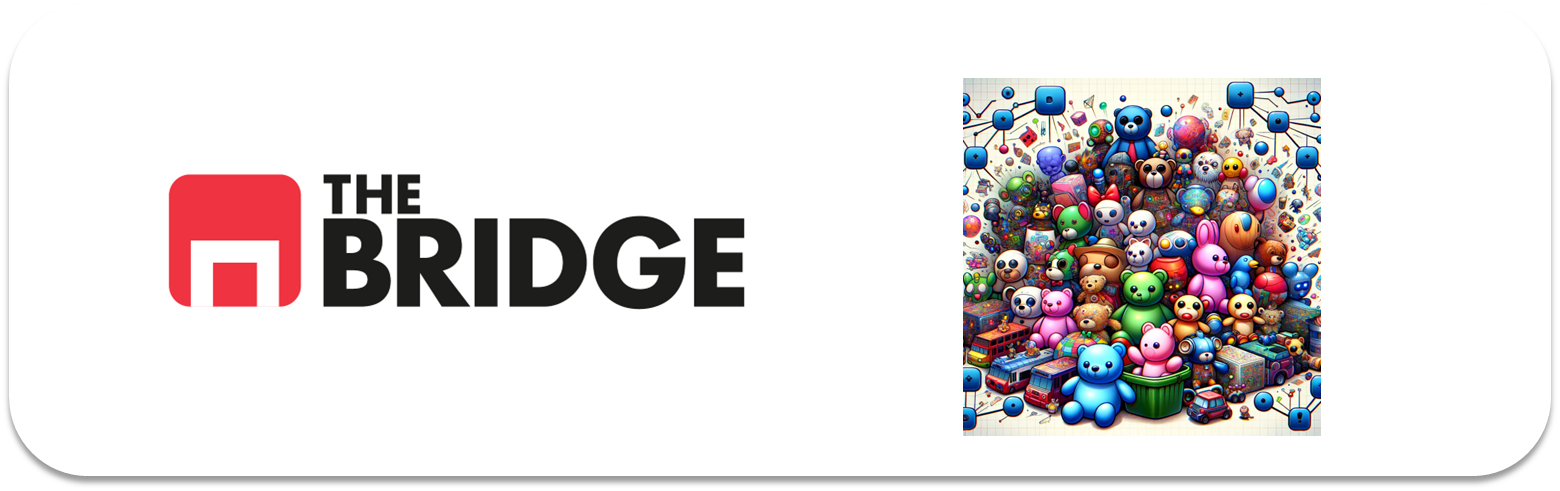

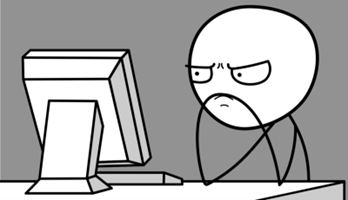

Para ejercitarte y afianzar lo aprendido sobre **K-Means**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Common imports
import numpy as np
import pandas as pd
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### Entendiendo el problema de negocio

En este notebook vamos a hacer un análisis de datos tirando de clusterizaciones para evaluar si existen grupos en nuestros productos, en este caso medicamentos, y posteriormente poder etiquetarlos. Poseemos información como rating, efectividad, efectos secundarios, entre otros.

### Ejercicio 1

Importa los datos, "./data/drugLibTrain_raw.tsv", que contiene un dataset con diferentes fármacos, sus efectos y ratings de los clientes de dichos fármacos. Realiza una inspección preliminar y quita las columnas que consideres innecesarias.

In [2]:
df = pd.read_csv("./data/drugLibTrain_raw.tsv", sep ="\t", index_col = 0)

In [3]:
df.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [4]:
df.shape

(3107, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 2202 to 2748
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   urlDrugName        3107 non-null   object
 1   rating             3107 non-null   int64 
 2   effectiveness      3107 non-null   object
 3   sideEffects        3107 non-null   object
 4   condition          3106 non-null   object
 5   benefitsReview     3089 non-null   object
 6   sideEffectsReview  3032 non-null   object
 7   commentsReview     3095 non-null   object
dtypes: int64(1), object(7)
memory usage: 218.5+ KB


In [6]:
df.describe()

,rating
count,3107.000000
mean,7.006115
std,2.937582
min,1.000000
25%,5.000000
50%,8.000000
75%,9.000000
max,10.000000


In [7]:
df.condition.nunique()

1426

In [8]:
df_clean = df.drop(columns=[
    "urlDrugName",
    "condition",
    "benefitsReview",
    "sideEffectsReview",
    "commentsReview"
])


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 2202 to 2748
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   rating         3107 non-null   int64 
 1   effectiveness  3107 non-null   object
 2   sideEffects    3107 non-null   object
dtypes: int64(1), object(2)
memory usage: 97.1+ KB


### Ejercicio 2: MiniEDA

Como es un problema no supervisado (vamos a intentar agrupar los medicamentos sin tener una referencia o target inicial), no hay split, vamos directos al miniEDA. Analiza qué variables son descartables en función de su porcentaje de cardinalidad. Es decir obten la cardinalidad y su porcentaje para cada posible feature y crea un dataset nuevo descartando las features que creas conveniente. NOTA: Como simplificación, descarta la columna con url.

In [10]:
cardinalidad = df_clean.nunique()
cardinalidad


rating           10
effectiveness     5
sideEffects       5
dtype: int64

In [11]:
card_df = pd.DataFrame({
    "Cardinalidad": df.nunique(),
    "Porcentaje_cardinalidad": (df.nunique() / len(df)) * 100
})

card_df.sort_values("Porcentaje_cardinalidad", ascending=False)


,Cardinalidad,Porcentaje_cardinalidad
commentsReview,3046,98.036691
benefitsReview,3031,97.553911
sideEffectsReview,2813,90.537496
condition,1426,45.896363
urlDrugName,502,16.157065
rating,10,0.321854
sideEffects,5,0.160927
effectiveness,5,0.160927


### Ejercicio 3

Construye un train set (llámalo X) sólo con las features que hayas seleccionado del ejercicio anterior (es decir las que no hayas descartado como posibles features) 

In [12]:
df_clean.columns

Index(['rating', 'effectiveness', 'sideEffects'], dtype='object')

In [13]:
X = df_clean.copy()

### Ejercicio 4 

Trasforma las features que consideres necesario (categóricas y numéricas) y luego aplica el escalado que consideres necesario.

In [14]:
for col in X.columns:
    print(f"For {col}:")
    print(X[col].unique())


For rating:
[ 4  1 10  3  2  9  7  8  6  5]
For effectiveness:
['Highly Effective' 'Marginally Effective' 'Ineffective'
 'Considerably Effective' 'Moderately Effective']
For sideEffects:
['Mild Side Effects' 'Severe Side Effects' 'No Side Effects'
 'Extremely Severe Side Effects' 'Moderate Side Effects']


In [15]:
# creat map to convert categorical variables into numeric using ordinal encoding, as values have a natural order
effectiveness_map = {
    "Ineffective": 1,
    "Marginally Effective": 2,
    "Moderately Effective": 3,
    "Considerably Effective": 4,
    "Highly Effective": 5
}

sideEffects_map = {
    "No Side Effects": 1,
    "Mild Side Effects": 2,
    "Moderate Side Effects": 3,
    "Severe Side Effects": 4,
    "Extremely Severe Side Effects": 5
}


In [16]:
# carry out ordinal mapping
X["effectiveness"] = X["effectiveness"].map(effectiveness_map)
X["sideEffects"] = X["sideEffects"].map(sideEffects_map)


In [17]:
X.head()

,rating,effectiveness,sideEffects
2202,4,5,2
3117,1,5,4
1146,10,5,1
3947,3,2,2
1951,2,2,4


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [25]:
pd.DataFrame(X_scaled).describe()


,0,1,2
count,3.107000e+03,3.107000e+03,3.107000e+03
mean,-1.863831e-16,-1.417884e-16,-1.800941e-17
std,1.000161e+00,1.000161e+00,1.000161e+00
min,-2.044907e+00,-2.386044e+00,-1.108302e+00
25%,-6.830236e-01,-7.604683e-01,-1.108302e+00
50%,3.383887e-01,5.231980e-02,-2.588954e-01
75%,6.788595e-01,8.651079e-01,5.905111e-01
max,1.019330e+00,8.651079e-01,2.289324e+00


### Ejercicio 5: Otención de K, aproximación visual

Analiza la relación entre features (con scatter plots) una vez transformadas para comprobar si existe visualmente algún indicio del número de clústeres que podríamos estar buscando. Por otro lado este análisis nos puede hacer descartar alguna feature o generar una nueva

In [26]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)


In [27]:
X_scaled_df.corr()


,rating,effectiveness,sideEffects
rating,1.000000,0.749962,-0.682905
effectiveness,0.749962,1.000000,-0.395310
sideEffects,-0.682905,-0.395310,1.000000


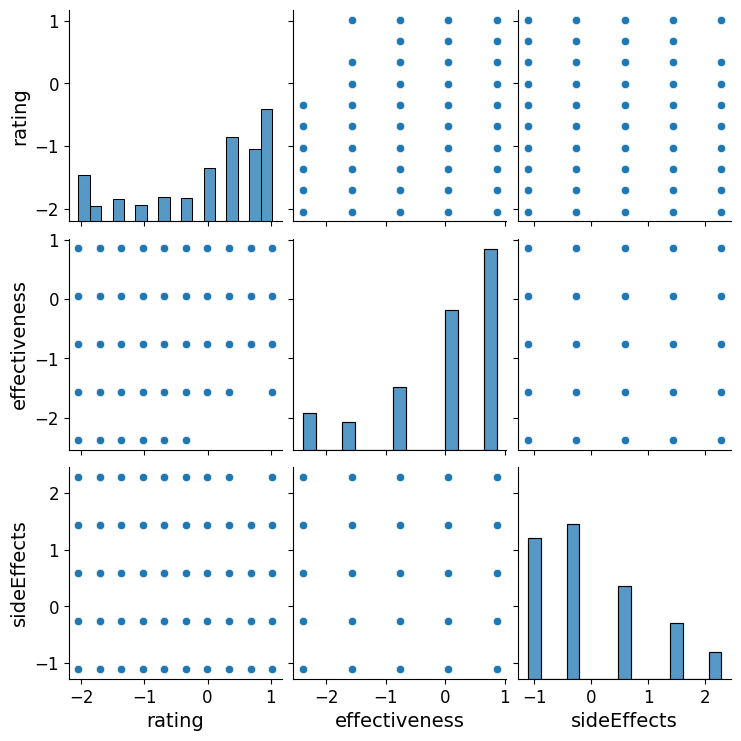

In [28]:
import seaborn as sns
sns.pairplot(X_scaled_df)


### Ejercicio 6: Obtención de K, método del codo

Evalua diferentes valores K y escoge uno a partir del método del codo/elbow de inercia.

In [30]:
from sklearn.cluster import KMeans

inercia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)


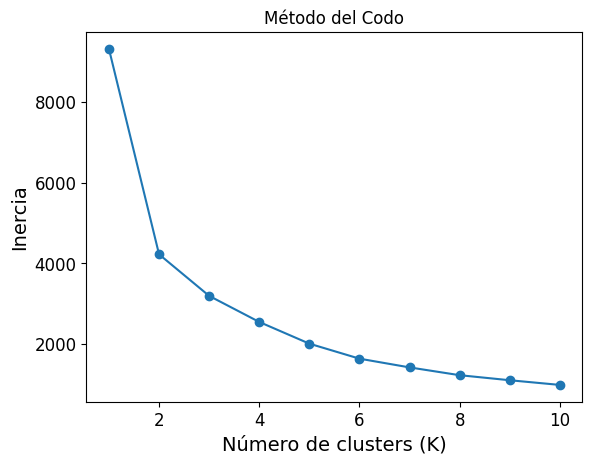

In [31]:
plt.figure()
plt.plot(K_range, inercia, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()


### Ejercicio 7: Obtención de K, Score de Silueta

Comprueba el ajuste de k obteniendo el k que maximiza el score de silueta y pinta un gráfico de la evolución de dicho score con k. Usa los valores de k que hayas probado en el ejercicio anterior.

In [36]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)


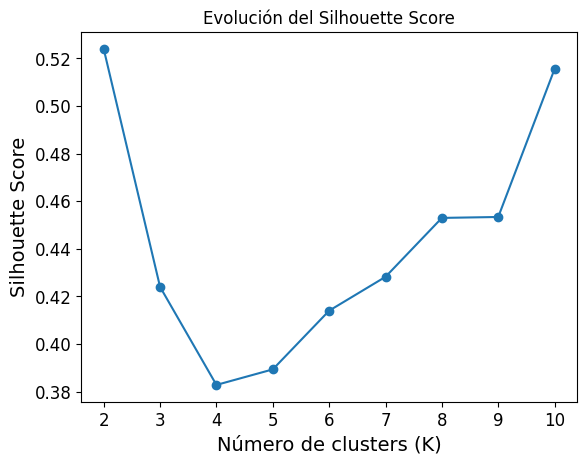

In [37]:
plt.figure()
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Evolución del Silhouette Score")
plt.show()


### Ejercicio 8: Obtención de K, diagrama de silueta

Para completar el estudio de k, muestra el diagramde silueta para k=2,3,4,5 y decide con este datos y los anteriores el valor de k a probar. NOTA: En la realidad, podríamos probar perfectamente k=2 y k=3 y luego que "Negocio" decidiera cuál le es más útil, aquí lo completamos por practicar todo lo aprendido

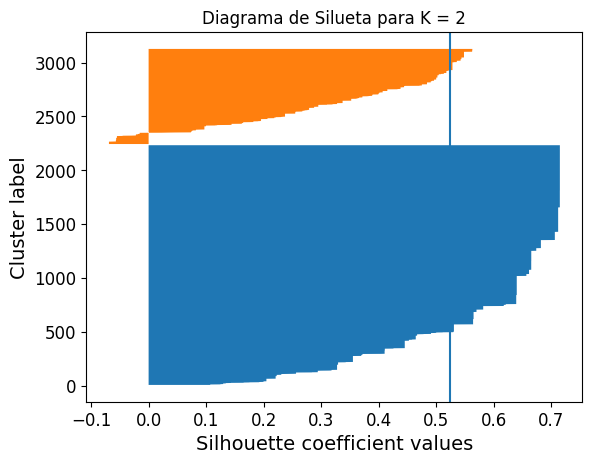

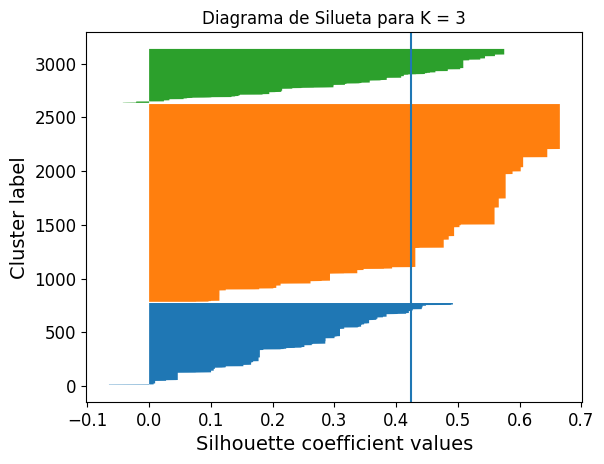

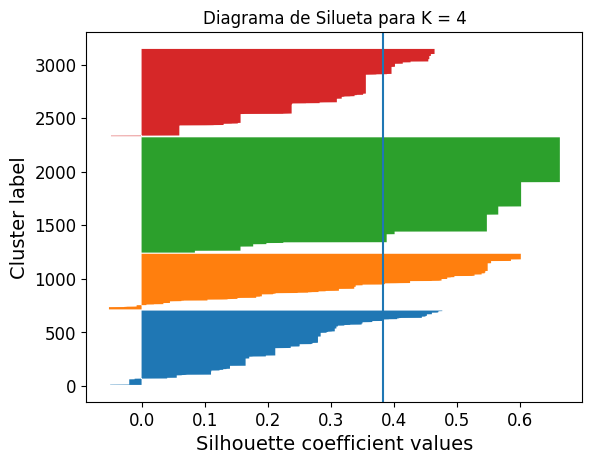

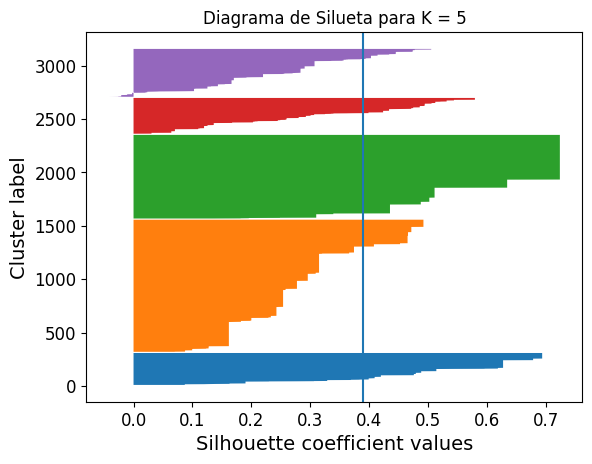

In [38]:
from sklearn.metrics import silhouette_samples

for k in [2, 3, 4, 5]:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    plt.figure()
    y_lower = 10
    
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values
        )
        
        y_lower = y_upper + 10

    plt.axvline(x=silhouette_avg)
    plt.title(f"Diagrama de Silueta para K = {k}")
    plt.xlabel("Silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.show()



### Ejercico 9:

En general, una diferencia entre el proceso de construcción de un modelo no supervisado y un supervisado es que el ajuste de algunos hiperparámetros (como el número de clústeres) es anterior a la construcción del modelo. Por eso, construye un K-means para el valor (o valores) de K escogidos.

In [39]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_final.fit(X_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [42]:
labels = kmeans_final.fit_predict(X_scaled)
labels

array([0, 1, 0, ..., 1, 0, 1], shape=(3107,), dtype=int32)

In [43]:
X_with_clusters = X.copy()
X_with_clusters["cluster"] = labels


In [44]:
X_with_clusters.groupby("cluster").mean()


,rating,effectiveness,sideEffects
cluster,,,
0,8.586331,4.475270,1.820594
1,3.026048,2.576444,3.524349


In [45]:
X_with_clusters["cluster"].value_counts()


cluster
0    2224
1     883
Name: count, dtype: int64

### Ejercicio 10

Vamos a comprobar resultados, analizando los valores medios y distribución de cada uno de los clústeres para el k óptimo. Si tuvieras más de un posible valor de k a probar, analiza aquí el de mayor score de silueta. Y utiliza el siguiente ejercicio para el otro. Además de hacer un describe de las features por clúster, pinta estos con un pairplot considerando sideEffects y rating como x e y (o viceversa) y el clúster como hue (color). Compara el resultado con los clústeres sugeridos en el ejercicio 5.

In [47]:
X_with_clusters.groupby("cluster").describe().T


cluster                        0           1
rating        count  2224.000000  883.000000
              mean      8.586331    3.026048
              std       1.325453    1.950755
              min       1.000000    1.000000
              25%       8.000000    1.000000
              50%       9.000000    3.000000
              75%      10.000000    5.000000
              max      10.000000   10.000000
effectiveness count  2224.000000  883.000000
              mean      4.475270    2.576444
              std       0.660103    1.284651
              min       2.000000    1.000000
              25%       4.000000    1.000000
              50%       5.000000    3.000000
              75%       5.000000    4.000000
              max       5.000000    5.000000
sideEffects   count  2224.000000  883.000000
              mean      1.820594    3.524349
              std       0.788302    1.111793
              min       1.000000    1.000000
              25%       1.000000    3.000000
              50%       2.000000    4.000000
              75%       2.000000    4.000000
              max       5.000000    5.000000

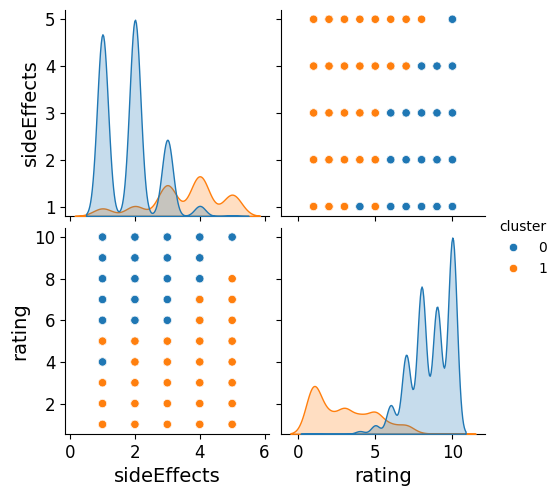

In [48]:
sns.pairplot(
    X_with_clusters,
    vars=["sideEffects", "rating"],
    hue="cluster"
)


### Ejercicio 11, EXTRA: Más valores de K

Repite el análisis del ejercicio 10 para un K diferente pero que consideres que tiene sentido aplicar.